# Paired ARCHS4–recount3 processing-robustness benchmark

**Question.** Does the frozen foundation model produce a consistent representation when the same human RNA-seq sample is processed independently by ARCHS4 and recount3?

This notebook is the human-readable analysis and report. It uses the 562 human GSM pairs from studies absent during training. It does **not** download data, preprocess expression, or regenerate embeddings. This tests robustness to the ARCHS4/recount3 processing differences, not batch correction or universal preprocessing invariance.

## Artifact map

This notebook is the analysis source of truth. `work/paired_expression/` and `work/recount3_embeddings.npy` are frozen inputs. `results/` contains the small tables written by this notebook. The remaining files under `work/` are provenance or restart artifacts.

In [4]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def find_benchmark_dir(start: Path) -> Path:
    """Find this benchmark whether Jupyter starts at repo/, benchmarks/, or here."""
    start = start.resolve()
    for parent in (start, *start.parents):
        if parent.name == 'paired_recount3' and (parent / 'config.json').is_file():
            return parent
        candidate = parent / 'benchmarks' / 'paired_recount3'
        if (candidate / 'config.json').is_file():
            return candidate
    raise FileNotFoundError(
        'Could not locate benchmarks/paired_recount3. Start Jupyter from the repository '
        'or one of its subdirectories.'
    )

HERE = find_benchmark_dir(Path.cwd())
WORK = HERE / 'work'
RESULTS = HERE / 'results'
repo = HERE.parents[1]
required = [
    WORK / 'paired_expression/samples.parquet',
    WORK / 'paired_expression/archs4_log1p_tpm.npy',
    WORK / 'paired_expression/recount3_log1p_tpm.npy',
    WORK / 'recount3_embeddings.npy',
    RESULTS / 'paired_metrics.parquet',
    RESULTS / 'full_archs4_retrieval.parquet',
    RESULTS / 'full_archs4_top10_neighbors.parquet',
]
missing = [path for path in required if not path.is_file()]
if missing:
    raise FileNotFoundError('Missing benchmark files:\n' + '\n'.join(f'  - {p}' for p in missing))
print(f'Benchmark directory: {HERE}')

all_samples = pd.read_parquet(WORK / 'paired_expression/samples.parquet')
keep = all_samples.study_exposure.eq('unseen_study').to_numpy()
samples = all_samples.loc[keep].reset_index(drop=True)
arch_expr = np.load(WORK / 'paired_expression/archs4_log1p_tpm.npy', mmap_mode='r')[keep]
recount_expr = np.load(WORK / 'paired_expression/recount3_log1p_tpm.npy', mmap_mode='r')[keep]
recount_embeddings = np.load(WORK / 'recount3_embeddings.npy', mmap_mode='r')[keep]

# Existing pairwise correlations are invariant to the retrieval search space.
existing_paired = pd.read_parquet(RESULTS / 'paired_metrics.parquet')
paired = samples.merge(existing_paired[['gsm', 'expression_pearson', 'expression_spearman']],
                       on='gsm', how='left', validate='one_to_one')
full = pd.read_parquet(RESULTS / 'full_archs4_retrieval.parquet')
full = full[full.gsm.isin(samples.gsm)].reset_index(drop=True)
neighbors = pd.read_parquet(RESULTS / 'full_archs4_top10_neighbors.parquet')
neighbors = neighbors[neighbors.query_gsm.isin(samples.gsm)].reset_index(drop=True)
assert len(samples) == len(paired) == len(full) == 562
print(f'Loaded {len(samples)} unseen-study GSM pairs; expression={arch_expr.shape}; embeddings={recount_embeddings.shape}')

Benchmark directory: /home/walt/bridge-rna/benchmarks/paired_recount3
Loaded 562 unseen-study GSM pairs; expression=(562, 15165); embeddings=(562, 512)


## 1. Sample set and provenance

In [5]:
pd.Series({'Samples': len(samples), 'Unique studies': samples.gse.nunique(),
           'Species': samples.species.unique().tolist(),
           'Exposure': samples.study_exposure.unique().tolist()}).to_frame('value')

,value
Samples,562
Unique studies,40
Species,[human]
Exposure,[unseen_study]


Every query is an unseen sample from a study absent during training. Each ARCHS4/recount3 pair is mapped into the same ordered 15,165-gene vocabulary and transformed to natural `log1p(TPM)` before encoding.

## 2. Expression and embedding agreement

,value
Median expression Pearson,0.9681
Median expression Spearman,0.9601
Median paired embedding cosine,0.9992


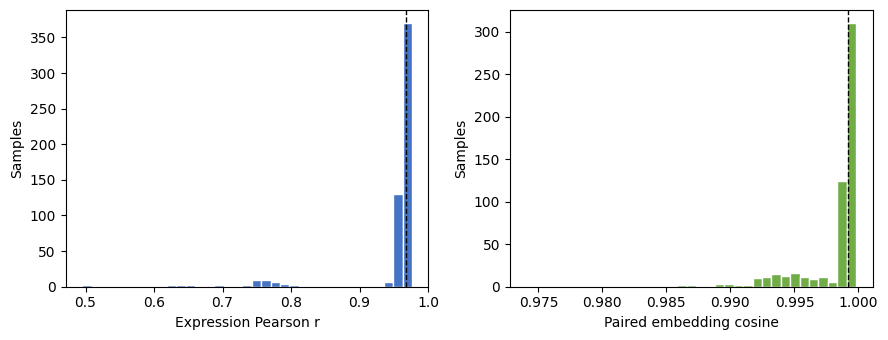

In [6]:
import json

# Recompute retrieval within the 562 unseen-study pairs.
embedding_dir = repo / 'embeddings/archs4'
locations = pd.read_parquet(embedding_dir / 'sample_locations.parquet')
location_index = samples[['gsm']].merge(locations[['geo_accession', 'global_index']],
    left_on='gsm', right_on='geo_accession', how='left', validate='one_to_one')
spec = json.loads((embedding_dir / 'embedding_manifest.json').read_text())
dtype = np.dtype(spec.get('embedding_dtype', 'float16'))
arch_memmap = np.memmap(embedding_dir / f'sample_embeddings.{dtype.name}.mmap', mode='r',
    dtype=dtype, shape=(spec['total_samples'], spec['embedding_dim']))
arch_embeddings = np.asarray(arch_memmap[location_index.global_index.astype(int)], dtype=np.float32)

def unit_rows(matrix):
    matrix = np.asarray(matrix, dtype=np.float32)
    return matrix / np.linalg.norm(matrix, axis=1, keepdims=True)

similarity = unit_rows(recount_embeddings) @ unit_rows(arch_embeddings).T
order = np.argsort(-similarity, axis=1)
row = np.arange(len(samples))
gse = samples.gse.astype(str).to_numpy()
paired['paired_cosine'] = similarity[row, row]
paired['exact_rank_paired'] = np.argmax(order == row[:, None], axis=1) + 1
paired['top1_gsm_paired'] = samples.gsm.to_numpy()[order[:, 0]]
paired['top1_same_gse_paired'] = gse[order[:, 0]] == gse
paired['top5_same_gse_paired'] = [np.any(gse[idx] == gse[i]) for i, idx in enumerate(order[:, :5])]

metadata = pd.read_parquet(repo / 'data/manifests/archs4_sample_metadata_v2.5.parquet')
meta = metadata.drop_duplicates('gsm').set_index('gsm')
failure_rows = []
for i in np.flatnonzero(paired.exact_rank_paired.gt(1)):
    winner = order[i, 0]
    query_gsm, top1_gsm = samples.iloc[i].gsm, samples.iloc[winner].gsm
    query_meta = meta.loc[query_gsm] if query_gsm in meta.index else pd.Series(dtype=object)
    top1_meta = meta.loc[top1_gsm] if top1_gsm in meta.index else pd.Series(dtype=object)
    query_tissue, top1_tissue = query_meta.get('source_name_ch1'), top1_meta.get('source_name_ch1')
    tissue_known = pd.notna(query_tissue) and pd.notna(top1_tissue)
    failure_rows.append({'query_gsm': query_gsm, 'query_gse': samples.iloc[i].gse,
      'correct_paired_gsm': query_gsm, 'top1_gsm_paired': top1_gsm, 'top1_gse': samples.iloc[winner].gse,
      'exact_rank_paired': paired.iloc[i].exact_rank_paired, 'correct_pair_cosine': similarity[i, i],
      'top1_cosine': similarity[i, winner], 'same_gse': gse[i] == gse[winner],
      'tissue': query_tissue, 'top1_tissue': top1_tissue,
      'same_tissue': (str(query_tissue).strip().lower() == str(top1_tissue).strip().lower()) if tissue_known else pd.NA,
      'condition_treatment': pd.NA, 'disease_state': pd.NA, 'replicate_information': pd.NA,
      'same_condition_treatment': pd.NA, 'same_disease_state': pd.NA, 'same_replicate': pd.NA,
      'title': query_meta.get('title'), 'characteristics_ch1': query_meta.get('characteristics_ch1'),
      'top1_title': top1_meta.get('title'), 'top1_characteristics_ch1': top1_meta.get('characteristics_ch1')})
failures = pd.DataFrame(failure_rows)

agreement = pd.Series({
    'Median expression Pearson': paired.expression_pearson.median(),
    'Median expression Spearman': paired.expression_spearman.median(),
    'Median paired embedding cosine': paired.paired_cosine.median(),
}).to_frame('value')
display(agreement.style.format('{:.4f}'))

fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
axes[0].hist(paired.expression_pearson, bins=35, color='#4472C4', edgecolor='white')
axes[0].axvline(paired.expression_pearson.median(), color='black', ls='--', lw=1)
axes[0].set(xlabel='Expression Pearson r', ylabel='Samples')
axes[1].hist(paired.paired_cosine, bins=35, color='#70AD47', edgecolor='white')
axes[1].axvline(paired.paired_cosine.median(), color='black', ls='--', lw=1)
axes[1].set(xlabel='Paired embedding cosine', ylabel='Samples')
fig.tight_layout();

## 3. Retrieval summary

In [7]:
summary = pd.DataFrame([
    {'Search space': f'Paired samples ({len(paired)})', 'Queries': len(paired),
     'Expression Pearson': paired.expression_pearson.median(), 'Expression Spearman': paired.expression_spearman.median(),
     'Paired cosine': paired.paired_cosine.median(), 'Exact R@1': paired.exact_rank_paired.le(1).mean(),
     'R@5': paired.exact_rank_paired.le(5).mean(), 'R@10': paired.exact_rank_paired.le(10).mean(),
     'R@100': paired.exact_rank_paired.le(100).mean(), 'Median rank': paired.exact_rank_paired.median(),
     'Median percentile': (1 - (paired.exact_rank_paired - 1) / len(paired)).median(),
     'Same-GSE R@1': paired.top1_same_gse_paired.mean(), 'Same-GSE R@5': paired.top5_same_gse_paired.mean()},
    {'Search space': f"Full human ARCHS4 ({int(full.database_samples.iloc[0]):,})", 'Queries': len(full),
     'Expression Pearson': paired.expression_pearson.median(),
     'Expression Spearman': paired.expression_spearman.median(), 'Paired cosine': full.paired_cosine.median(),
     'Exact R@1': full.exact_rank_full.le(1).mean(), 'R@5': full.exact_rank_full.le(5).mean(),
     'R@10': full.exact_rank_full.le(10).mean(), 'R@100': full.exact_rank_full.le(100).mean(),
     'Median rank': full.exact_rank_full.median(), 'Median percentile': full.percentile_rank_full.median(),
     'Same-GSE R@1': full.top1_same_gse_full.mean(), 'Same-GSE R@5': full.top5_same_gse_full.mean()}])
publication = summary.copy()
percent_cols = ['Exact R@1', 'R@5', 'R@10', 'R@100', 'Same-GSE R@1', 'Same-GSE R@5']
formatters = {column: '{:.1%}' for column in percent_cols}
formatters.update({column: '{:.4f}' for column in ['Expression Pearson', 'Expression Spearman', 'Paired cosine']})
formatters['Median percentile'] = '{:.6f}'
display(publication.style.format(formatters, na_rep='—').hide(axis='index'))

Search space,Queries,Expression Pearson,Expression Spearman,Paired cosine,Exact R@1,R@5,R@10,R@100,Median rank,Median percentile,Same-GSE R@1,Same-GSE R@5
Paired samples (562),562,0.9681,0.9601,0.9992,58.7%,84.2%,92.0%,99.8%,1.000000,1.000000,98.2%,100.0%
"Full human ARCHS4 (510,709)",562,0.9681,0.9601,0.9992,28.5%,69.6%,77.2%,91.8%,2.000000,0.999998,76.2%,85.6%


The paired search asks whether each recount3 query retrieves its matching GSM among only the 562 unseen-study ARCHS4 samples. The full search repeats the test against every human sample in the ARCHS4 embedding database. Same-GSE retrieval is complementary: a nonidentical sample from the same study may be biologically near-indistinguishable.

## 4. What are the paired Top-1 failures?

In [8]:
def known_rate(frame, column):
    known = frame[column].dropna()
    return pd.Series({'Determinate failures': len(known), 'Matching': int(known.sum()),
                      'Proportion': known.mean() if len(known) else np.nan})

failure_summary = pd.DataFrame({
    'Same GSE': known_rate(failures, 'same_gse'),
    'Same tissue/source label': known_rate(failures, 'same_tissue'),
    'Same condition/treatment': known_rate(failures, 'same_condition_treatment'),
    'Same disease state': known_rate(failures, 'same_disease_state'),
    'Same replicate': known_rate(failures, 'same_replicate'),
}).T
display(failure_summary.style.format({'Proportion': '{:.1%}'}, na_rep='Not determinable'))

failure_columns = ['query_gsm', 'query_gse', 'top1_gsm_paired', 'top1_gse',
                   'exact_rank_paired', 'correct_pair_cosine', 'top1_cosine',
                   'same_gse', 'tissue', 'top1_tissue', 'same_tissue']
display(failures.sort_values('exact_rank_paired', ascending=False)[failure_columns].head(12))

,Determinate failures,Matching,Proportion
Same GSE,232.000000,222.000000,95.7%
Same tissue/source label,232.000000,180.000000,77.6%
Same condition/treatment,0.000000,0.000000,Not determinable
Same disease state,0.000000,0.000000,Not determinable
Same replicate,0.000000,0.000000,Not determinable


,query_gsm,query_gse,top1_gsm_paired,top1_gse,exact_rank_paired,correct_pair_cosine,top1_cosine,same_gse,tissue,top1_tissue,same_tissue
46,GSM7461704,GSE234297,GSM7461828,GSE234297,109,0.996349,0.999281,True,peripheral blood,peripheral blood,True
89,GSM7461768,GSE234297,GSM7461737,GSE234297,95,0.997250,0.999513,True,peripheral blood,peripheral blood,True
100,GSM7461798,GSE234297,GSM7461828,GSE234297,49,0.998961,0.999686,True,peripheral blood,peripheral blood,True
74,GSM7461743,GSE234297,GSM7461828,GSE234297,47,0.998756,0.999456,True,peripheral blood,peripheral blood,True
117,GSM7461824,GSE234297,GSM7461714,GSE234297,41,0.997082,0.998806,True,peripheral blood,peripheral blood,True
57,GSM7461716,GSE234297,GSM7461778,GSE234297,40,0.997487,0.999050,True,peripheral blood,peripheral blood,True
114,GSM7461818,GSE234297,GSM7461738,GSE234297,38,0.998742,0.999467,True,peripheral blood,peripheral blood,True
45,GSM7461703,GSE234297,GSM7461772,GSE234297,37,0.998874,0.999455,True,peripheral blood,peripheral blood,True
98,GSM7461795,GSE234297,GSM7461828,GSE234297,34,0.998916,0.999576,True,peripheral blood,peripheral blood,True
194,GSM938907,GSE38233,GSM938908,GSE38233,32,0.977721,0.988244,True,cultured B-cells,cultured B-cells,True


ARCHS4 provides free-text titles, source names, and characteristics—not curated tissue, treatment, disease, or replicate fields. Tissue/source agreement above is therefore an exact normalized match of the available `source_name_ch1` label. The other biological categories remain explicitly indeterminate rather than being inferred from free text. The full failure table is saved as `results/paired_top1_failures.parquet`.

## 5. Full human ARCHS4 retrieval

In [9]:
full_metrics = pd.Series({
    'Human ARCHS4 database samples': int(full.database_samples.iloc[0]),
    'Exact R@1': full.exact_rank_full.le(1).mean(),
    'Exact R@5': full.exact_rank_full.le(5).mean(),
    'Exact R@10': full.exact_rank_full.le(10).mean(),
    'Exact R@100': full.exact_rank_full.le(100).mean(),
    'Median exact rank': full.exact_rank_full.median(),
    'Median percentile rank': full.percentile_rank_full.median(),
    'Same-GSE Top-1': full.top1_same_gse_full.mean(),
    'Same-GSE Top-5': full.top5_same_gse_full.mean(),
}).to_frame('value')
display(full_metrics)
display(neighbors.head(10))

,value
Human ARCHS4 database samples,510709.000000
Exact R@1,0.284698
Exact R@5,0.695730
Exact R@10,0.772242
Exact R@100,0.918149
Median exact rank,2.000000
Median percentile rank,0.999998
Same-GSE Top-1,0.761566
Same-GSE Top-5,0.855872


,query_gsm,query_gse,rank,neighbor_gsm,cosine_similarity,is_exact_gsm,neighbor_gse,same_gse,tissue_or_source,title,characteristics
0,GSM6597903,GSE214017,1,GSM6597930,0.996851,False,GSE214017,True,ctrl6,nucleus_ml240_ctrl6,"cell type: ipsn,cell line: ctrl6,genotype: wil..."
1,GSM6597903,GSE214017,2,GSM6597906,0.996844,False,GSE214017,True,ctrl6,nucleus_untreated_ctrl6,"cell type: ipsn,cell line: ctrl6,genotype: wil..."
2,GSM6597903,GSE214017,3,GSM6597912,0.996536,False,GSE214017,True,ncrme6,nucleus_untreated_ncrme6,"cell type: ipsn,cell line: ncrme6,genotype: vc..."
3,GSM6597903,GSE214017,4,GSM6597932,0.996239,False,GSE214017,True,glib,nucleus_ml240_glib,"cell type: ipsn,cell line: glib,genotype: vcp ..."
4,GSM6597903,GSE214017,5,GSM6597908,0.996202,False,GSE214017,True,glib,nucleus_untreated_glib,"cell type: ipsn,cell line: glib,genotype: vcp ..."
5,GSM6597903,GSE214017,6,GSM6597907,0.995827,False,GSE214017,True,glia,nucleus_untreated_glia,"cell type: ipsn,cell line: glia,genotype: vcp ..."
6,GSM6597903,GSE214017,7,GSM6597927,0.995686,False,GSE214017,True,ctrl1,nucleus_ml240_ctrl1,"cell type: ipsn,cell line: ctrl1,genotype: wil..."
7,GSM6597903,GSE214017,8,GSM6597931,0.995675,False,GSE214017,True,glia,nucleus_ml240_glia,"cell type: ipsn,cell line: glia,genotype: vcp ..."
8,GSM6597903,GSE214017,9,GSM6597935,0.995252,False,GSE214017,True,ncrmc2,nucleus_ml240_ncrmc2,"cell type: ipsn,cell line: ncrmc2,genotype: vc..."
9,GSM6597903,GSE214017,10,GSM6597929,0.994907,False,GSE214017,True,ctrl4,nucleus_ml240_ctrl4,"cell type: ipsn,cell line: ctrl4,genotype: wil..."


`results/full_archs4_top10_neighbors.parquet` contains all ten neighbors for every query, including GSE, cosine similarity, title, tissue/source, and raw characteristics where available.

## 6. Retrieval outliers: processing disagreement or dense neighborhood?

Candidate outliers are the union of the ten lowest expression-Pearson samples, ten lowest paired-cosine samples, and ten worst full-corpus exact ranks. `processing_disagreement` requires expression Pearson or Spearman in the bottom decile **and** paired cosine in the bottom decile. `dense_neighborhood` requires full-corpus rank >10 with Pearson and Spearman ≥0.90 and paired cosine ≥0.99. Remaining candidates are `unclear`. Neighborhood counts include samples whose cosine is at least the exact-pair cosine minus the stated tolerance. These prespecified categories are diagnostic, not biological labels.

In [10]:
paired_with_full = paired.merge(full[['gsm', 'exact_rank_full']], on='gsm', how='left')
candidate_gsms = pd.unique(pd.concat([
    paired_with_full.nsmallest(10, 'expression_pearson').gsm,
    paired_with_full.nsmallest(10, 'paired_cosine').gsm,
    paired_with_full.nlargest(10, 'exact_rank_full').gsm]))
outliers = paired_with_full[paired_with_full.gsm.isin(candidate_gsms)].copy()
low_expression = (outliers.expression_pearson.le(paired.expression_pearson.quantile(.10)) |
                  outliers.expression_spearman.le(paired.expression_spearman.quantile(.10)))
low_cosine = outliers.paired_cosine.le(paired.paired_cosine.quantile(.10))
dense = (outliers.exact_rank_full.gt(10) & outliers.expression_pearson.ge(.90) &
         outliers.expression_spearman.ge(.90) & outliers.paired_cosine.ge(.99))
outliers['tentative_category'] = np.select(
    [low_expression & low_cosine, dense],
    ['processing_disagreement', 'dense_neighborhood'], default='unclear')

# Vectorized cosine search for this small candidate set against all human ARCHS4 embeddings.
manifest = pd.read_parquet(repo / 'data/manifests/sample_manifest.parquet', columns=['gsm', 'species'])
human_locations = locations.merge(manifest, left_on='geo_accession', right_on='gsm',
                                  how='left', validate='one_to_one')
human_locations = human_locations[human_locations.species.astype('string').str.lower().eq('human')]
human_vectors = np.asarray(arch_memmap[human_locations.global_index.to_numpy(dtype=np.int64)], dtype=np.float32)
candidate_positions = samples.reset_index().set_index('gsm').loc[outliers.gsm, 'index'].to_numpy()
candidate_scores = unit_rows(recount_embeddings[candidate_positions]) @ unit_rows(human_vectors).T
exact_cosine = outliers.paired_cosine.to_numpy()
outliers['samples_within_0.001'] = (candidate_scores >= exact_cosine[:, None] - .001).sum(axis=1)
outliers['samples_within_0.005'] = (candidate_scores >= exact_cosine[:, None] - .005).sum(axis=1)
del candidate_scores, human_vectors

top10 = neighbors[neighbors.query_gsm.isin(outliers.gsm)].copy()
top1_cosine = top10[top10['rank'].eq(1)].set_index('query_gsm').cosine_similarity
outliers['top1_cosine'] = outliers.gsm.map(top1_cosine)
outliers['top1_minus_exact_cosine'] = outliers.top1_cosine - outliers.paired_cosine
outliers['top10_same_gse_proportion'] = outliers.gsm.map(top10.groupby('query_gsm').same_gse.mean())
query_tissue = metadata.drop_duplicates('gsm').set_index('gsm').source_name_ch1
top10['query_tissue'] = top10.query_gsm.map(query_tissue)
known_tissue = top10.query_tissue.notna() & top10.tissue_or_source.notna()
top10['same_tissue'] = pd.Series(pd.NA, index=top10.index, dtype='boolean')
top10.loc[known_tissue, 'same_tissue'] = (
    top10.loc[known_tissue, 'query_tissue'].str.strip().str.lower().to_numpy() ==
    top10.loc[known_tissue, 'tissue_or_source'].str.strip().str.lower().to_numpy())
outliers['top10_same_tissue_proportion'] = outliers.gsm.map(
    top10.groupby('query_gsm').same_tissue.apply(lambda x: x.dropna().mean() if x.notna().any() else np.nan))

assay_columns = ['gsm', 'series_id', 'source_name_ch1', 'library_strategy', 'library_source',
                 'instrument_model', 'platform_id', 'title', 'characteristics_ch1']
outliers = outliers.merge(metadata[assay_columns].drop_duplicates('gsm'), on='gsm', how='left')
outlier_columns = ['tentative_category', 'gsm', 'gse', 'expression_pearson', 'expression_spearman',
                   'paired_cosine', 'exact_rank_paired', 'exact_rank_full', 'top1_cosine', 'top1_minus_exact_cosine',
                   'samples_within_0.001', 'samples_within_0.005', 'top10_same_gse_proportion',
                   'top10_same_tissue_proportion', 'source_name_ch1', 'library_strategy',
                   'library_source', 'instrument_model', 'platform_id']
display(outliers[outlier_columns].sort_values(['tentative_category', 'exact_rank_full']))

processing = outliers[outliers.tentative_category.eq('processing_disagreement')]
protocol_clusters = (processing.groupby(['gse', 'library_strategy', 'library_source', 'instrument_model'],
                                         dropna=False).size().rename('outliers').reset_index()
                     .sort_values('outliers', ascending=False))
display(protocol_clusters.head(10))

,tentative_category,gsm,gse,expression_pearson,expression_spearman,paired_cosine,exact_rank_paired,exact_rank_full,top1_cosine,top1_minus_exact_cosine,samples_within_0.001,samples_within_0.005,top10_same_gse_proportion,top10_same_tissue_proportion,source_name_ch1,library_strategy,library_source,instrument_model,platform_id
0,dense_neighborhood,GSM7461704,GSE234297,0.961767,0.951008,0.996349,109,3186,0.999281,0.002932,5836,14804,0.4,0.4,peripheral blood,RNA-Seq,transcriptomic,Illumina HiSeq 2000,GPL11154
3,dense_neighborhood,GSM7461824,GSE234297,0.963487,0.950703,0.997082,41,4766,0.999090,0.002008,8379,16563,0.1,0.2,peripheral blood,RNA-Seq,transcriptomic,Illumina HiSeq 2000,GPL11154
2,dense_neighborhood,GSM7461768,GSE234297,0.966807,0.954412,0.997250,95,5322,0.999513,0.002263,8035,15628,0.7,0.7,peripheral blood,RNA-Seq,transcriptomic,Illumina HiSeq 2000,GPL11154
1,dense_neighborhood,GSM7461716,GSE234297,0.966802,0.956018,0.997487,40,5809,0.999063,0.001576,9599,17752,0.3,0.3,peripheral blood,RNA-Seq,transcriptomic,Illumina HiSeq 2000,GPL11154
9,processing_disagreement,GSM8020745,GSE253440,0.753510,0.756431,0.981911,1,2,0.983556,0.001645,2,12,0.1,0.1,Peripheral blood primary human neutrophil,RNA-Seq,transcriptomic,Illumina NextSeq 500,GPL18573
10,processing_disagreement,GSM8121059,GSE260619,0.637006,0.634463,0.984819,1,22,0.992041,0.007222,27,73,0.0,0.0,Human post-mortem brain WM,RNA-Seq,transcriptomic,Illumina HiSeq 2500,GPL16791
8,processing_disagreement,GSM8020744,GSE253440,0.592580,0.663694,0.990232,2,308,0.995604,0.005372,416,684,0.0,0.0,Peripheral blood primary human neutrophil,RNA-Seq,transcriptomic,Illumina NextSeq 500,GPL18573
7,processing_disagreement,GSM8020743,GSE253440,0.548766,0.641592,0.989782,4,382,0.996216,0.006434,468,756,0.0,0.0,Peripheral blood primary human neutrophil,RNA-Seq,transcriptomic,Illumina NextSeq 500,GPL18573
4,processing_disagreement,GSM8020740,GSE253440,0.495094,0.621546,0.987286,1,475,0.995751,0.008465,540,691,0.0,0.0,Peripheral blood primary human neutrophil,RNA-Seq,transcriptomic,Illumina NextSeq 500,GPL18573
6,processing_disagreement,GSM8020742,GSE253440,0.510630,0.644313,0.987114,1,495,0.995968,0.008854,555,680,0.0,0.0,Peripheral blood primary human neutrophil,RNA-Seq,transcriptomic,Illumina NextSeq 500,GPL18573


,gse,library_strategy,library_source,instrument_model,outliers
0,GSE253440,RNA-Seq,transcriptomic,Illumina NextSeq 500,6
3,GSE40137,RNA-Seq,transcriptomic,Illumina HiSeq 2000,6
1,GSE260619,RNA-Seq,transcriptomic,Illumina HiSeq 2500,1
2,GSE38233,RNA-Seq,transcriptomic,Illumina HiSeq 2000,1


## Save and reproduce the result tables

Running this notebook from top to bottom performs the analysis from the frozen matrices and embeddings. The final cell saves the small publication tables under `results/`.

In [11]:
RESULTS.mkdir(parents=True, exist_ok=True)
paired.to_parquet(RESULTS / 'paired_metrics.parquet', index=False)
failures.to_parquet(RESULTS / 'paired_top1_failures.parquet', index=False)
full.to_parquet(RESULTS / 'full_archs4_retrieval.parquet', index=False)
neighbors.to_parquet(RESULTS / 'full_archs4_top10_neighbors.parquet', index=False)
outliers.to_parquet(RESULTS / 'retrieval_outlier_characterization.parquet', index=False)
summary.to_csv(RESULTS / 'benchmark_summary.csv', index=False)
print(f'Saved unseen-study-only results to {RESULTS}')

Saved unseen-study-only results to /home/walt/bridge-rna/benchmarks/paired_recount3/results
